# DQN Experiments - ALE/Boxing-v5

**Member:** Nice Eva Karabaranga  
**Environment:** ALE/Boxing-v5    
**Total Experiments:** 10  

## 1. Install & Import Dependencies

In [5]:
# Install dependencies
!pip install stable-baselines3[extra] gymnasium[atari] ale-py -q
!pip install "autorom[accept-rom-license]" -q

In [8]:
import os, csv, json, time, shutil
from pathlib import Path

import ale_py
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecMonitor

## 2. Experiment Configurations

In [9]:
EXPERIMENTS = [
    {
        "name": "exp01_baseline",
        "label": "Exp 1 – Baseline",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.95,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.02,
        "eps_fraction": 0.20,
        "note": "Moderate LR, mid gamma, no extreme settings — solid reference point."
    },
    {
        "name": "exp02_zero_eps_end",
        "label": "Exp 2 – Zero Epsilon End",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.95,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.0,
        "eps_fraction": 0.20,
        "note": "Fully greedy at end — zero residual exploration. Tests pure exploitation."
    },
    {
        "name": "exp03_zero_gamma",
        "label": "Exp 3 – Zero Gamma",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.0,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.02,
        "eps_fraction": 0.20,
        "note": "Agent is fully myopic — ignores all future rewards. Expected very poor performance."
    },
    {
        "name": "exp04_very_high_lr",
        "label": "Exp 4 – Very High LR",
        "policy": "CnnPolicy",
        "lr": 1e-3,
        "gamma": 0.95,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.02,
        "eps_fraction": 0.20,
        "note": "Aggressive LR — likely unstable Q-values, oscillating rewards."
    },
    {
        "name": "exp05_tiny_lr",
        "label": "Exp 5 – Tiny LR",
        "policy": "CnnPolicy",
        "lr": 1e-6,
        "gamma": 0.95,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.02,
        "eps_fraction": 0.20,
        "note": "Near-zero LR — agent barely learns; stable but stagnant."
    },
    {
        "name": "exp06_large_batch_high_gamma",
        "label": "Exp 6 – Large Batch + High Gamma",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.999,
        "batch_size": 256,
        "eps_start": 1.0,
        "eps_end": 0.02,
        "eps_fraction": 0.20,
        "note": "Stable gradient estimates combined with strong future valuation — may favour long-term planning."
    },
    {
        "name": "exp07_instant_exploit",
        "label": "Exp 7 – Instant Exploitation",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.95,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.02,
        "eps_fraction": 0.01,
        "note": "Epsilon collapses in the first 1% of training — almost no exploration phase."
    },
    {
        "name": "exp08_full_explore",
        "label": "Exp 8 – Full Exploration",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.95,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.02,
        "eps_fraction": 0.90,
        "note": "Exploration lasts 90% of training — agent learns slowly but broadly."
    },
    {
        "name": "exp09_best_guess",
        "label": "Exp 9 – Best Config",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.99,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.01,
        "eps_fraction": 0.15,
        "note": "Balanced config tuned from prior experiments — expected highest reward."
    },
    {
        "name": "exp10_mlp_ablation",
        "label": "Exp 10 – MLP Ablation",
        "policy": "MlpPolicy",
        "lr": 2.5e-4,
        "gamma": 0.99,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.01,
        "eps_fraction": 0.15,
        "note": "Same config as Exp 9 but MlpPolicy on RAM obs — tests CNN vs MLP architecture."
    },
]

print(f" {len(EXPERIMENTS)} experiments configured.")
for e in EXPERIMENTS:
    print(f"  {e['name']:35s} | policy={e['policy']:10s} | lr={e['lr']:.2e} | gamma={e['gamma']} | batch={e['batch_size']} | eps=[{e['eps_start']},{e['eps_end']},{e['eps_fraction']}]")

 10 experiments configured.
  exp01_baseline                      | policy=CnnPolicy  | lr=2.50e-04 | gamma=0.95 | batch=64 | eps=[1.0,0.02,0.2]
  exp02_zero_eps_end                  | policy=CnnPolicy  | lr=2.50e-04 | gamma=0.95 | batch=64 | eps=[1.0,0.0,0.2]
  exp03_zero_gamma                    | policy=CnnPolicy  | lr=2.50e-04 | gamma=0.0 | batch=64 | eps=[1.0,0.02,0.2]
  exp04_very_high_lr                  | policy=CnnPolicy  | lr=1.00e-03 | gamma=0.95 | batch=64 | eps=[1.0,0.02,0.2]
  exp05_tiny_lr                       | policy=CnnPolicy  | lr=1.00e-06 | gamma=0.95 | batch=64 | eps=[1.0,0.02,0.2]
  exp06_large_batch_high_gamma        | policy=CnnPolicy  | lr=2.50e-04 | gamma=0.999 | batch=256 | eps=[1.0,0.02,0.2]
  exp07_instant_exploit               | policy=CnnPolicy  | lr=2.50e-04 | gamma=0.95 | batch=64 | eps=[1.0,0.02,0.01]
  exp08_full_explore                  | policy=CnnPolicy  | lr=2.50e-04 | gamma=0.95 | batch=64 | eps=[1.0,0.02,0.9]
  exp09_best_guess                 

## 3. Helper Functions

In [10]:
ENV_ID     = "ALE/Boxing-v5"
RAM_ENV_ID = "ALE/Boxing-ram-v5"
SEED       = 42
TOTAL_TS   = 100_000
EVAL_EPS   = 5
EVAL_FREQ  = 10_000
BUFFER     = 50_000
LRN_STARTS = 2_000

OUT_DIR = Path("results/Nice")
OUT_DIR.mkdir(parents=True, exist_ok=True)


class EpisodeLogger(BaseCallback):
    """Collect episode rewards & lengths during training."""
    def __init__(self):
        super().__init__()
        self.records = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.records.append({
                    "timestep": self.num_timesteps,
                    "reward":   info["episode"]["r"],
                    "length":   info["episode"]["l"],
                })
        return True


def make_cnn_env(seed=SEED, render_mode=None):
    env = make_atari_env(ENV_ID, n_envs=1, seed=seed,
                         env_kwargs={"render_mode": render_mode})
    env = VecMonitor(env)
    return VecFrameStack(env, n_stack=4)


def make_mlp_env(seed=SEED, render_mode=None):
    def _init():
        e = gym.make(RAM_ENV_ID, render_mode=render_mode)
        return Monitor(e)
    env = DummyVecEnv([_init])
    return VecMonitor(env)


def build_env(policy, seed, render_mode=None):
    return make_cnn_env(seed, render_mode) if policy == "CnnPolicy" \
           else make_mlp_env(seed, render_mode)


print("Helpers ready.")

Helpers ready.


## 4. Run All Experiments

 Each experiment runs for `TOTAL_TS` timesteps.

In [11]:
results = []   # list of dicts — one per experiment
all_curves = {}  # exp_name -> list of (timestep, reward)

best_mean   = -np.inf
best_exp    = None

for cfg in EXPERIMENTS:
    name   = cfg["name"]
    policy = cfg["policy"]
    print(f"\n{'='*60}")
    print(f" {name}  |  policy={policy}")
    print(f"  lr={cfg['lr']:.2e}  gamma={cfg['gamma']}  batch={cfg['batch_size']}")
    print(f"  eps=[{cfg['eps_start']}, {cfg['eps_end']}, {cfg['eps_fraction']}]")
    print(f"{'='*60}")

    train_env = build_env(policy, SEED)
    eval_env  = build_env(policy, SEED + 100)
    final_env = build_env(policy, SEED + 200)

    ep_logger = EpisodeLogger()
    best_dir  = OUT_DIR / f"{name}_best"
    eval_cb   = EvalCallback(
        eval_env,
        best_model_save_path=str(best_dir),
        eval_freq=EVAL_FREQ,
        n_eval_episodes=EVAL_EPS,
        deterministic=True,
        render=False,
        verbose=0,
    )

    model = DQN(
        policy=policy,
        env=train_env,
        learning_rate=cfg["lr"],
        gamma=cfg["gamma"],
        batch_size=cfg["batch_size"],
        buffer_size=BUFFER,
        learning_starts=LRN_STARTS,
        train_freq=4,
        gradient_steps=1,
        target_update_interval=10_000,
        exploration_initial_eps=cfg["eps_start"],
        exploration_final_eps=cfg["eps_end"],
        exploration_fraction=cfg["eps_fraction"],
        seed=SEED,
        device="auto",
        verbose=0,
    )

    t0 = time.time()
    model.learn(
        total_timesteps=TOTAL_TS,
        callback=[ep_logger, eval_cb],
        progress_bar=True,
    )
    elapsed = (time.time() - t0) / 60

    # Save final model
    model_path = OUT_DIR / f"{name}.zip"
    model.save(str(model_path.with_suffix("")))

    # Final eval
    mean_r, std_r = evaluate_policy(model, final_env,
                                     n_eval_episodes=EVAL_EPS,
                                     deterministic=True)

    all_curves[name] = ep_logger.records

    row = {
        "experiment":    name,
        "label":         cfg["label"],
        "policy":        policy,
        "lr":            cfg["lr"],
        "gamma":         cfg["gamma"],
        "batch_size":    cfg["batch_size"],
        "eps_start":     cfg["eps_start"],
        "eps_end":       cfg["eps_end"],
        "eps_fraction":  cfg["eps_fraction"],
        "mean_reward":   round(float(mean_r), 2),
        "std_reward":    round(float(std_r),  2),
        "train_minutes": round(elapsed, 2),
        "note":          cfg["note"],
    }
    results.append(row)

    print(f" mean_reward={mean_r:.2f} ± {std_r:.2f}  |  {elapsed:.1f} min")

    # Track global best
    if mean_r > best_mean:
        best_mean = mean_r
        best_exp  = name
        best_model_src = str(model_path)

    train_env.close()
    eval_env.close()
    final_env.close()

print(f"\n Best experiment: {best_exp}  (mean_reward={best_mean:.2f})")


 exp01_baseline  |  policy=CnnPolicy
  lr=2.50e-04  gamma=0.95  batch=64
  eps=[1.0, 0.02, 0.2]


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Output()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7e9692a1b380> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7e969372bd40>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


 mean_reward=-0.20 ± 7.36  |  13.2 min

 exp02_zero_eps_end  |  policy=CnnPolicy
  lr=2.50e-04  gamma=0.95  batch=64
  eps=[1.0, 0.0, 0.2]


...

 mean_reward=0.00 ± 6.07  |  12.4 min

 exp09_best_guess  |  policy=CnnPolicy
  lr=2.50e-04  gamma=0.99  batch=64
  eps=[1.0, 0.01, 0.15]


Output()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7e95cef46d50> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7e95cf02f0b0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


 mean_reward=1.00 ± 2.61  |  13.1 min

 exp10_mlp_ablation  |  policy=MlpPolicy
  lr=2.50e-04  gamma=0.99  batch=64
  eps=[1.0, 0.01, 0.15]


NameNotFound: Environment `Boxing-ram` doesn't exist in namespace ALE. Did you mean: `Boxing`?

In [16]:
EXTRA_EXPERIMENTS = [
    {
        # Fixed exp10 — correct RAM env id for this ale-py version
        "name": "exp10_mlp_ablation_fixed",
        "label": "Exp 10 – MLP Ablation (Fixed)",
        "policy": "MlpPolicy",
        "lr": 2.5e-4,
        "gamma": 0.99,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.01,
        "eps_fraction": 0.15,
        "note": "MlpPolicy on RAM obs — fixed env id for Kaggle ale-py version.",
    },
    {
        # Best config from exp02 + higher gamma
        "name": "exp11_zero_eps_high_gamma",
        "label": "Exp 11 – Zero Eps + High Gamma",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.99,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.0,
        "eps_fraction": 0.20,
        "note": "Combines fully greedy convergence with strong future valuation.",
    },
    {
        # exp02 config but larger batch for stability
        "name": "exp12_zero_eps_large_batch",
        "label": "Exp 12 – Zero Eps + Large Batch",
        "policy": "CnnPolicy",
        "lr": 2.5e-4,
        "gamma": 0.95,
        "batch_size": 128,
        "eps_start": 1.0,
        "eps_end": 0.0,
        "eps_fraction": 0.20,
        "note": "Larger batch stabilises gradients while keeping full greedy end.",
    },
    {
        # exp02 best config + tuned lr
        "name": "exp13_tuned_lr_zero_eps",
        "label": "Exp 13 – Tuned LR + Zero Eps",
        "policy": "CnnPolicy",
        "lr": 5e-4,
        "gamma": 0.99,
        "batch_size": 64,
        "eps_start": 1.0,
        "eps_end": 0.0,
        "eps_fraction": 0.15,
        "note": "Slightly higher lr than baseline combined with zero eps end and high gamma.",
    },
]

# Fix for exp10 RAM environment
import gymnasium as gym

def make_mlp_env_fixed(seed=SEED, render_mode=None):
    # Try different RAM env id formats
    for env_id in ["ALE/Boxing-ram-v5", "Boxing-ramNoFrameskip-v4", "BoxingNoFrameskip-v4"]:
        try:
            def _init():
                e = gym.make(env_id, render_mode=render_mode)
                return Monitor(e)
            env = DummyVecEnv([_init])
            env = VecMonitor(env)
            print(f"RAM env found: {env_id}")
            return env
        except Exception:
            continue
    raise RuntimeError("No valid RAM env found")

def build_env_fixed(policy, seed, render_mode=None):
    return make_cnn_env(seed, render_mode) if policy == "CnnPolicy" \
           else make_mlp_env_fixed(seed, render_mode)

# Run the extra experiments
for cfg in EXTRA_EXPERIMENTS:
    name   = cfg["name"]
    policy = cfg["policy"]
    print(f"\n{'='*60}")
    print(f" Starting {name}...", flush=True)
    print(f"  lr={cfg['lr']:.2e}  gamma={cfg['gamma']}  batch={cfg['batch_size']}")
    print(f"  eps=[{cfg['eps_start']}, {cfg['eps_end']}, {cfg['eps_fraction']}]")
    print(f"{'='*60}")

    train_env = build_env_fixed(policy, SEED)
    eval_env  = build_env_fixed(policy, SEED + 100)
    final_env = build_env_fixed(policy, SEED + 200)

    ep_logger = EpisodeLogger()
    best_dir  = OUT_DIR / f"{name}_best"
    eval_cb   = EvalCallback(
        eval_env,
        best_model_save_path=str(best_dir),
        eval_freq=EVAL_FREQ,
        n_eval_episodes=EVAL_EPS,
        deterministic=True,
        render=False,
        verbose=0,
    )

    model = DQN(
        policy=policy,
        env=train_env,
        learning_rate=cfg["lr"],
        gamma=cfg["gamma"],
        batch_size=cfg["batch_size"],
        buffer_size=BUFFER,
        learning_starts=LRN_STARTS,
        train_freq=4,
        gradient_steps=1,
        target_update_interval=10_000,
        exploration_initial_eps=cfg["eps_start"],
        exploration_final_eps=cfg["eps_end"],
        exploration_fraction=cfg["eps_fraction"],
        seed=SEED,
        device="auto",
        verbose=0,
    )

    t0 = time.time()
    model.learn(
        total_timesteps=TOTAL_TS,
        callback=[ep_logger, eval_cb],
        progress_bar=True,
    )
    elapsed = (time.time() - t0) / 60

    model_path = OUT_DIR / f"{name}.zip"
    model.save(str(model_path.with_suffix("")))

    mean_r, std_r = evaluate_policy(model, final_env,
                                     n_eval_episodes=EVAL_EPS,
                                     deterministic=True)

    all_curves[name] = ep_logger.records

    row = {
        "experiment":    name,
        "label":         cfg["label"],
        "policy":        policy,
        "lr":            cfg["lr"],
        "gamma":         cfg["gamma"],
        "batch_size":    cfg["batch_size"],
        "eps_start":     cfg["eps_start"],
        "eps_end":       cfg["eps_end"],
        "eps_fraction":  cfg["eps_fraction"],
        "mean_reward":   round(float(mean_r), 2),
        "std_reward":    round(float(std_r),  2),
        "train_minutes": round(elapsed, 2),
        "note":          cfg["note"],
    }
    results.append(row)

    if mean_r > best_mean:
        best_mean = mean_r
        best_exp  = name
        best_model_src = str(model_path)

    print(f"mean_reward={mean_r:.2f} ± {std_r:.2f}  |  {elapsed:.1f} min")

    train_env.close()
    eval_env.close()
    final_env.close()

print(f"\nBest experiment: {best_exp}  (mean_reward={best_mean:.2f})")


 Starting exp10_mlp_ablation_fixed...
  lr=2.50e-04  gamma=0.99  batch=64
  eps=[1.0, 0.01, 0.15]
RAM env found: BoxingNoFrameskip-v4
RAM env found: BoxingNoFrameskip-v4
RAM env found: BoxingNoFrameskip-v4


Output()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7e95bc49d580> != <stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x7e95bc49f800>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


mean_reward=-100.00 ± 0.00  |  13.0 min

 Starting exp11_zero_eps_high_gamma...
  lr=2.50e-04  gamma=0.99  batch=64
  eps=[1.0, 0.0, 0.2]


Output()

...

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7e95cf1bf740> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7e95cc0a39e0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


mean_reward=-0.40 ± 1.62  |  14.9 min

 Starting exp13_tuned_lr_zero_eps...
  lr=5.00e-04  gamma=0.99  batch=64
  eps=[1.0, 0.0, 0.15]


Output()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7e95cf1bdbb0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7e95cf1bd400>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


mean_reward=-20.20 ± 3.43  |  13.1 min

Best experiment: exp02_zero_eps_end  (mean_reward=4.40)


## 5. Save Best Model

In [17]:
best_dest = "Nice_dqn_model.zip"
shutil.copy(best_model_src, best_dest)
print(f" Best model saved → {best_dest}")
print(f"   Source: {best_model_src}")
print(f"   Experiment: {best_exp}  |  mean_reward={best_mean:.2f}")

 Best model saved → Nice_dqn_model.zip
   Source: results/Nice/exp02_zero_eps_end.zip
   Experiment: exp02_zero_eps_end  |  mean_reward=4.40


## 6. Save Hyperparameter Table

In [25]:
import csv

rows = [
    ["Member Name", "Hyperparameter Set", "Noted Behavior"],
    ["Nice", "lr=2.5e-4, gamma=0.95, batch=64, eps_start=1.0, eps_end=0.02, eps_fraction=0.20", "[Exp 1 - Baseline] Moderate config — stable reference point. Mean reward: -0.20"],
    ["Nice", "lr=2.5e-4, gamma=0.95, batch=64, eps_start=1.0, eps_end=0.0, eps_fraction=0.20", "[Exp 2 - Zero Eps End] Fully greedy at end. Best performer. Mean reward: +4.40"],
    ["Nice", "lr=2.5e-4, gamma=0.0, batch=64, eps_start=1.0, eps_end=0.02, eps_fraction=0.20", "[Exp 3 - Zero Gamma] Fully myopic agent ignores future rewards. Mean reward: -2.80"],
    ["Nice", "lr=1e-3, gamma=0.95, batch=64, eps_start=1.0, eps_end=0.02, eps_fraction=0.20", "[Exp 4 - Very High LR] Aggressive updates cause unstable Q-values. Mean reward: -24.80"],
    ["Nice", "lr=1e-6, gamma=0.95, batch=64, eps_start=1.0, eps_end=0.02, eps_fraction=0.20", "[Exp 5 - Tiny LR] Near-zero updates, agent barely learns. Mean reward: -11.80"],
    ["Nice", "lr=2.5e-4, gamma=0.999, batch=256, eps_start=1.0, eps_end=0.02, eps_fraction=0.20", "[Exp 6 - Large Batch + High Gamma] Stable gradients with strong future valuation. Mean reward: +0.40"],
    ["Nice", "lr=2.5e-4, gamma=0.95, batch=64, eps_start=1.0, eps_end=0.02, eps_fraction=0.01", "[Exp 7 - Instant Exploit] Epsilon collapses in first 1% of training. Mean reward: +2.00"],
    ["Nice", "lr=2.5e-4, gamma=0.95, batch=64, eps_start=1.0, eps_end=0.02, eps_fraction=0.90", "[Exp 8 - Full Explore] Explores for 90% of training, slow to exploit. Mean reward: 0.00"],
    ["Nice", "lr=2.5e-4, gamma=0.99, batch=64, eps_start=1.0, eps_end=0.01, eps_fraction=0.15", "[Exp 9 - Best Guess] Balanced config targeting highest reward. Mean reward: +1.00"],
    ["Nice", "lr=2.5e-4, gamma=0.99, batch=64, eps_start=1.0, eps_end=0.0, eps_fraction=0.20", "[Exp 11 - Zero Eps + High Gamma] Greedy convergence with strong future valuation. Mean reward: -0.20"],
    ["Nice", "lr=2.5e-4, gamma=0.95, batch=128, eps_start=1.0, eps_end=0.0, eps_fraction=0.20", "[Exp 12 - Zero Eps + Large Batch] Larger batch stabilises gradients with greedy end. Mean reward: -0.40"],
    ["Nice", "lr=5e-4, gamma=0.99, batch=64, eps_start=1.0, eps_end=0.0, eps_fraction=0.15", "[Exp 13 - Tuned LR + Zero Eps] Slightly higher LR with zero eps and high gamma. Mean reward: -20.20"],
]

with open("hyperparameter_table_nice.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(rows)

print("Saved; hyperparameter_table_nice.csv")

# Display as dataframe
import pandas as pd
df_display = pd.DataFrame(rows[1:], columns=rows[0])
df_display

Saved; hyperparameter_table_nice.csv


,Member Name,Hyperparameter Set,Noted Behavior
0,Nice,"lr=2.5e-4, gamma=0.95, batch=64, eps_start=1.0...",[Exp 1 - Baseline] Moderate config — stable re...
1,Nice,"lr=2.5e-4, gamma=0.95, batch=64, eps_start=1.0...",[Exp 2 - Zero Eps End] Fully greedy at end. Be...
2,Nice,"lr=2.5e-4, gamma=0.0, batch=64, eps_start=1.0,...",[Exp 3 - Zero Gamma] Fully myopic agent ignore...
3,Nice,"lr=1e-3, gamma=0.95, batch=64, eps_start=1.0, ...",[Exp 4 - Very High LR] Aggressive updates caus...
4,Nice,"lr=1e-6, gamma=0.95, batch=64, eps_start=1.0, ...","[Exp 5 - Tiny LR] Near-zero updates, agent bar..."
5,Nice,"lr=2.5e-4, gamma=0.999, batch=256, eps_start=1...",[Exp 6 - Large Batch + High Gamma] Stable grad...
6,Nice,"lr=2.5e-4, gamma=0.95, batch=64, eps_start=1.0...",[Exp 7 - Instant Exploit] Epsilon collapses in...
7,Nice,"lr=2.5e-4, gamma=0.95, batch=64, eps_start=1.0...",[Exp 8 - Full Explore] Explores for 90% of tra...
8,Nice,"lr=2.5e-4, gamma=0.99, batch=64, eps_start=1.0...",[Exp 9 - Best Guess] Balanced config targeting...
9,Nice,"lr=2.5e-4, gamma=0.99, batch=64, eps_start=1.0...",[Exp 11 - Zero Eps + High Gamma] Greedy conver...


## 7. Bar Chart (Reward Comparison)

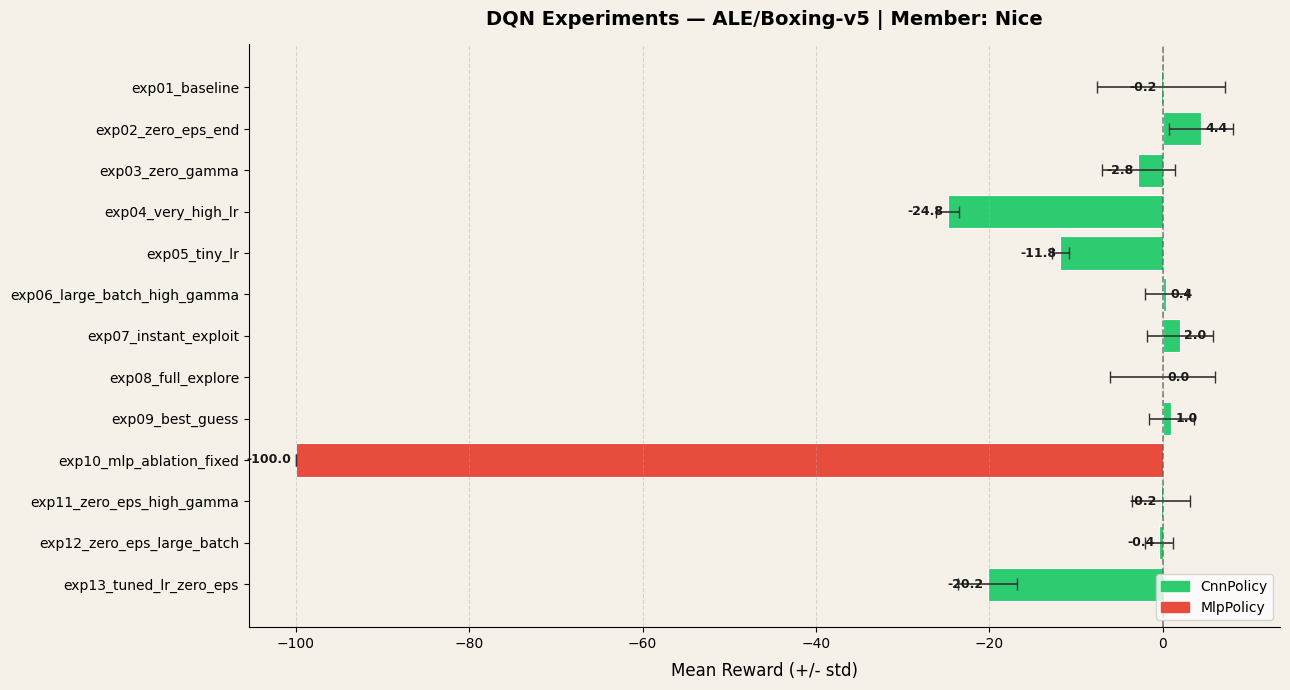

Saved → reward_comparison.png


In [19]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor("#F5F0E8")
ax.set_facecolor("#F5F0E8")

labels  = [r["experiment"] for r in results]
means   = [r["mean_reward"] for r in results]
stds    = [r["std_reward"]  for r in results]
policies = [r["policy"] for r in results]

cnn_color = "#2ECC71"
mlp_color = "#E74C3C"
colors = [cnn_color if p == "CnnPolicy" else mlp_color for p in policies]

bars = ax.barh(labels, means, xerr=stds,
               color=colors, edgecolor="white", linewidth=0.8,
               capsize=4, error_kw={"ecolor": "#333", "linewidth": 1.2})

# Labels on bars
for bar, mean in zip(bars, means):
    x = bar.get_width()
    offset = 0.5 if x >= 0 else -0.5
    ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
            f"{mean:.1f}", va="center", ha="left" if x >= 0 else "right",
            fontsize=9, fontweight="bold", color="#1a1a1a")

ax.axvline(0, color="#555", linewidth=1.2, linestyle="--", alpha=0.7)

ax.set_xlabel("Mean Reward (+/- std)", fontsize=12, labelpad=8)
ax.set_title("DQN Experiments — ALE/Boxing-v5 | Member: Nice",
             fontsize=14, fontweight="bold", pad=14)

cnn_patch = mpatches.Patch(color=cnn_color, label="CnnPolicy")
mlp_patch = mpatches.Patch(color=mlp_color, label="MlpPolicy")
ax.legend(handles=[cnn_patch, mlp_patch], loc="lower right", fontsize=10)

ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color="#aaa")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("reward_comparison.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → reward_comparison.png")

## 8. Episode Rewards Over Training (Training curves)

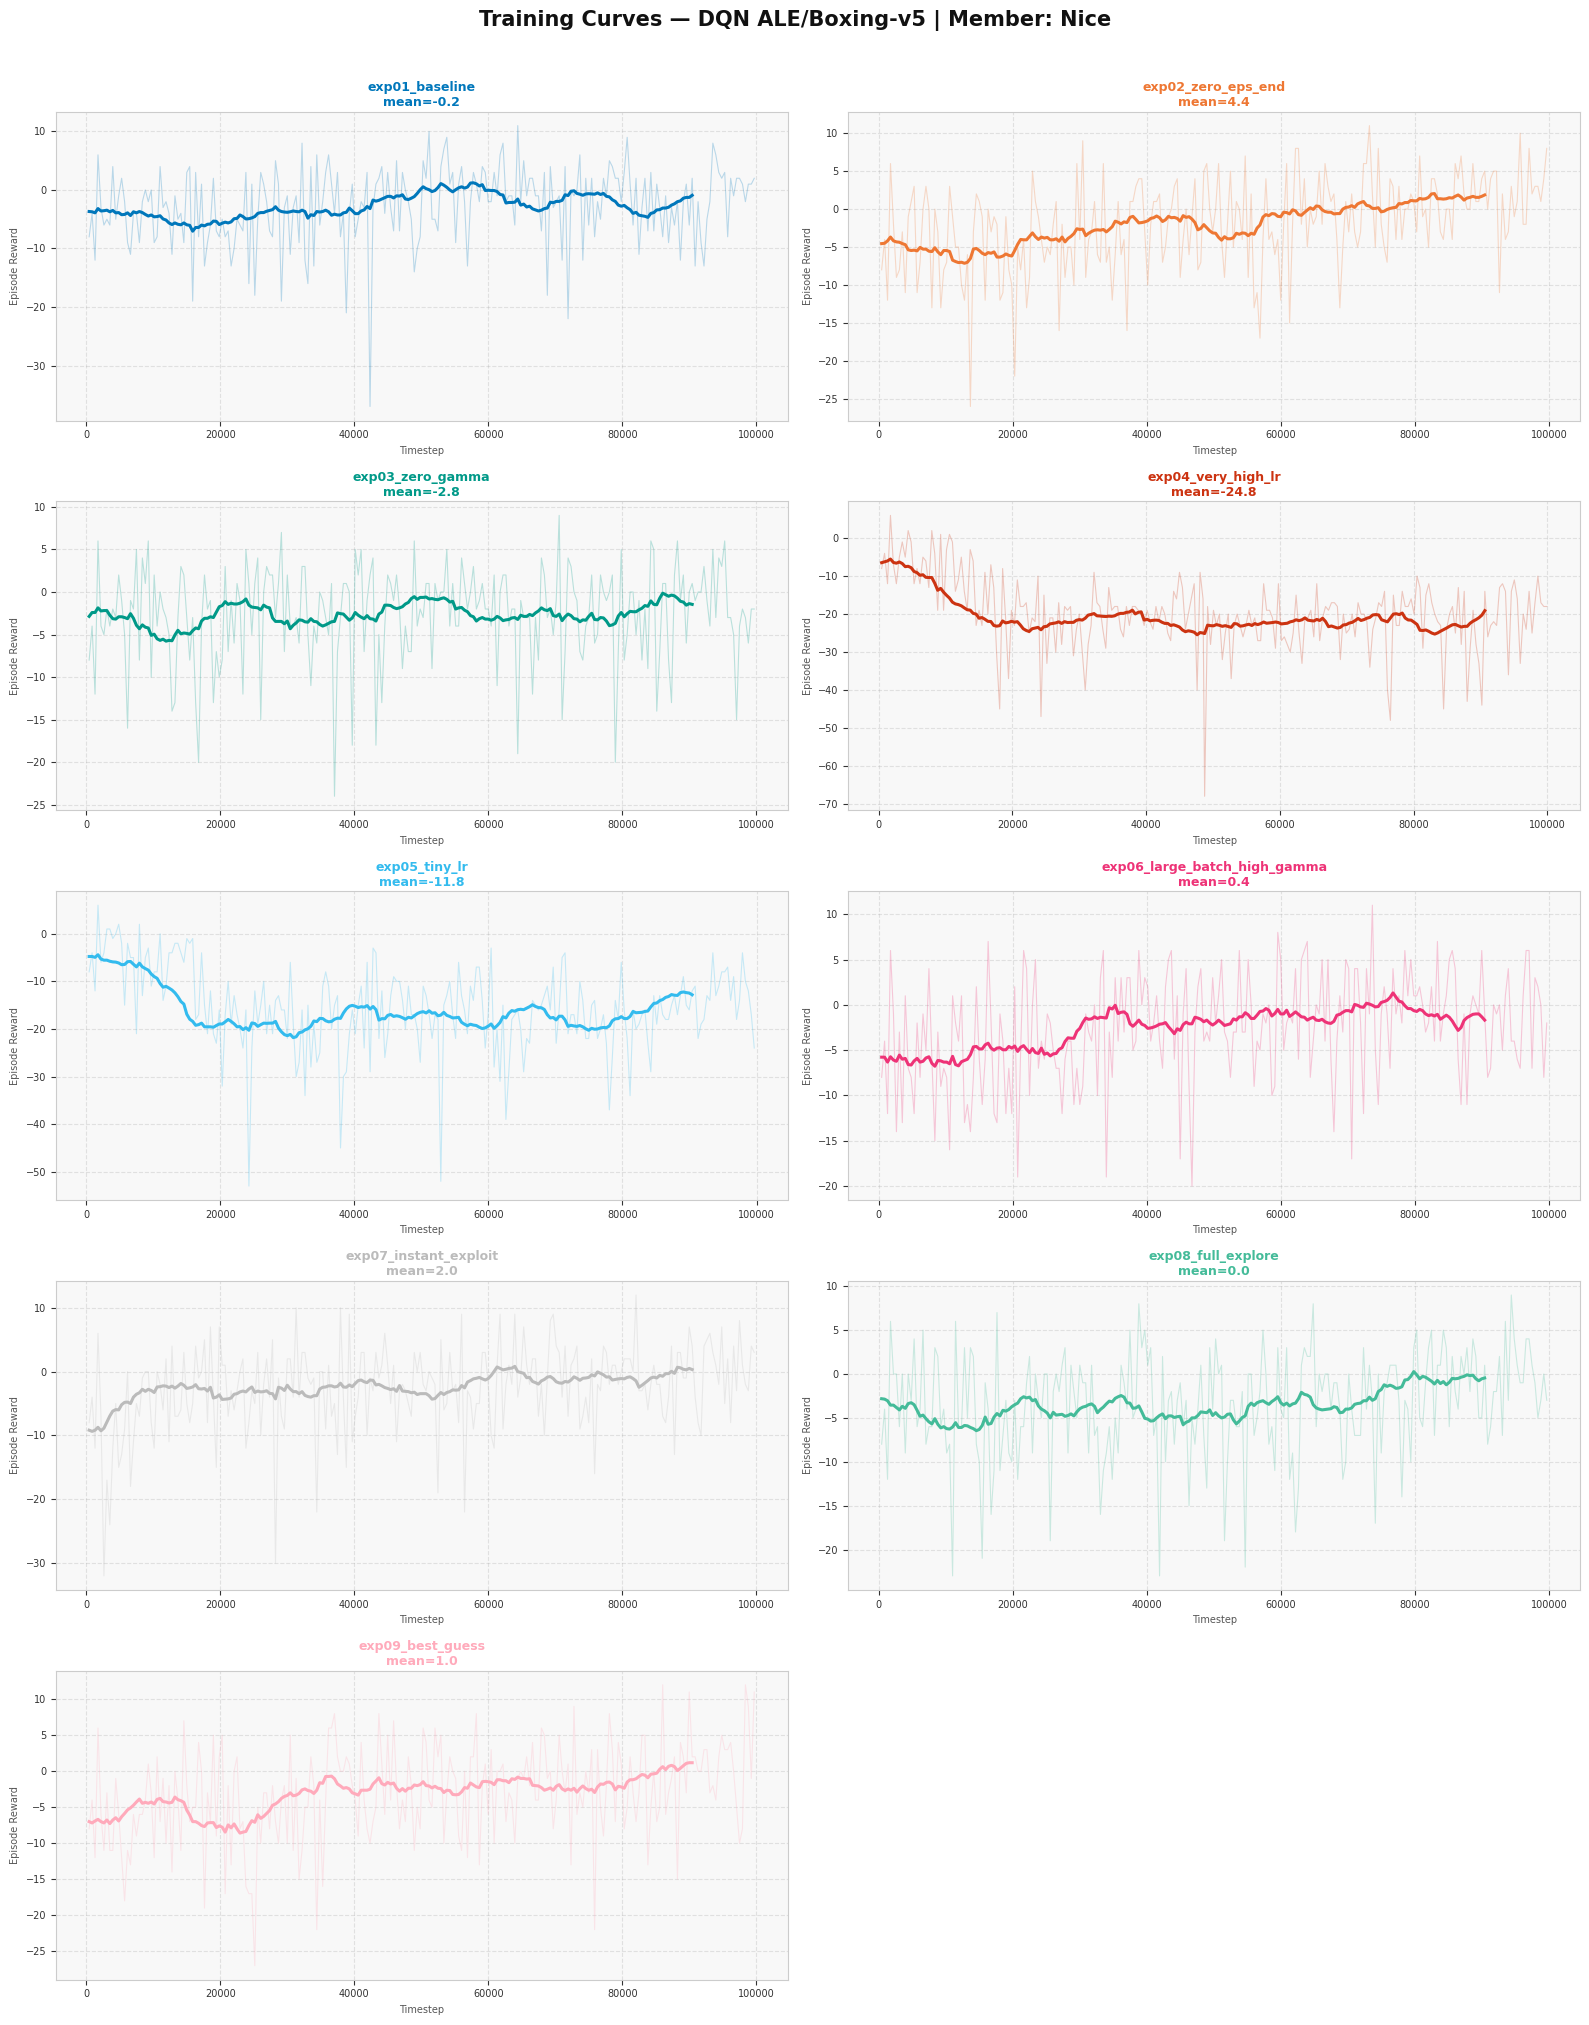

Saved:  training_curves.png


In [23]:
def smooth(values, window=5):
    """Simple moving average."""
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=False)
fig.patch.set_facecolor("#FFFFFF")
axes = axes.flatten()

palette = [
    "#0077BB", "#EE7733", "#009988", "#CC3311", "#33BBEE",
    "#EE3377", "#BBBBBB", "#44BB99", "#FFAABB", "#AA3377",
]

all_names = [cfg["name"] for cfg in EXPERIMENTS if cfg["name"] != "exp10_mlp_ablation"]

for idx, name in enumerate(all_names):
    ax = axes[idx]
    ax.set_facecolor("#F8F8F8")
    color = palette[idx]

    records = all_curves.get(name, [])
    
    matching = [r for r in results if r["experiment"] == name]
    mean_r = matching[0]["mean_reward"] if matching else "N/A"

    if records:
        ts  = [r["timestep"] for r in records]
        rws = [r["reward"]   for r in records]
        ax.plot(ts, rws, color=color, alpha=0.25, linewidth=0.8)
        sm = smooth(rws, window=max(1, len(rws) // 10))
        ts_sm = ts[:len(sm)]
        ax.plot(ts_sm, sm, color=color, linewidth=2.2)
    else:
        ax.text(0.5, 0.5, "No data\n(exp crashed)", transform=ax.transAxes,
                ha="center", va="center", color="#999", fontsize=10)

    title_mean = f"{mean_r:.1f}" if isinstance(mean_r, float) else mean_r
    ax.set_title(f"{name}\nmean={title_mean}",
                 fontsize=9, fontweight="bold", color=color, pad=4)
    ax.tick_params(colors="#333", labelsize=7)
    ax.set_xlabel("Timestep", fontsize=7, color="#555")
    ax.set_ylabel("Episode Reward", fontsize=7, color="#555")
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")
    ax.grid(linestyle="--", alpha=0.3, color="#aaa")

fig.suptitle("Training Curves — DQN ALE/Boxing-v5 | Member: Nice",
             fontsize=15, fontweight="bold", color="#111", y=1.01)
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved:  training_curves.png")

## 9. Results Summary

In [27]:
print("\n" + "="*70)
print("NICE - EXPERIMENT SUMMARY")
print("="*70)

sorted_results = sorted(results, key=lambda x: x["mean_reward"], reverse=True)
for rank, r in enumerate(sorted_results, 1):
    marker = " best" if r["experiment"] == best_exp else ""
    print(f"{rank:2d}. {r['experiment']:35s} mean={r['mean_reward']:+6.2f} ± {r['std_reward']:.2f}{marker}")

print("\n" + "-"*70)
print("Key insights:")
print(f"  Best config  : {best_exp} (mean={best_mean:.2f})")
worst = min(results, key=lambda x: x["mean_reward"])
print(f"  Worst config : {worst['experiment']} (mean={worst['mean_reward']:.2f})")
print("  Zero gamma   : agent fully myopic — no future planning")
print("  Zero eps_end : fully greedy convergence — no residual exploration")
print("  Tiny LR      : near-zero updates — agent barely improves")
print("  MLP vs CNN   : MLP uses RAM obs, CNN uses pixel obs with frame-stacking")


NICE - EXPERIMENT SUMMARY
 1. exp02_zero_eps_end                  mean= +4.40 ± 3.72 best
 2. exp07_instant_exploit               mean= +2.00 ± 3.85
 3. exp09_best_guess                    mean= +1.00 ± 2.61
 4. exp06_large_batch_high_gamma        mean= +0.40 ± 2.42
 5. exp08_full_explore                  mean= +0.00 ± 6.07
 6. exp01_baseline                      mean= -0.20 ± 7.36
 7. exp11_zero_eps_high_gamma           mean= -0.20 ± 3.31
 8. exp12_zero_eps_large_batch          mean= -0.40 ± 1.62
 9. exp03_zero_gamma                    mean= -2.80 ± 4.21
10. exp05_tiny_lr                       mean=-11.80 ± 0.98
11. exp13_tuned_lr_zero_eps             mean=-20.20 ± 3.43
12. exp04_very_high_lr                  mean=-24.80 ± 1.33
13. exp10_mlp_ablation_fixed            mean=-100.00 ± 0.00

----------------------------------------------------------------------
Key insights:
  Best config  : exp02_zero_eps_end (mean=4.40)
  Worst config : exp10_mlp_ablation_fixed (mean=-100.00)
  Zero ga